# 🚴 Analyse Spark - Données Vélib' Paris

**Objectif** : Analyser les données Vélib' depuis Elasticsearch avec Apache Spark

---

## 📦 Installation des dépendances

In [1]:
# Installation du connecteur Elasticsearch pour Spark
!pip install elasticsearch==8.11.0 pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 8.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.2 MB/s eta 0:00:00


## 🔧 Configuration Spark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, min, max, count, sum as spark_sum,
    hour, dayofweek, date_format, when, round as spark_round
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json

# Configuration de l'affichage
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Imports réussis")

✅ Imports réussis


In [ ]:
# Fermer toute session Spark existante et créer une nouvelle avec ES 9.x connector
try:
    spark.stop()
except:
    pass

# Créer la session Spark avec connector Elasticsearch compatible ES 9.x
spark = SparkSession.builder \
    .appName("VelibAnalysis") \
    .config("spark.jars.packages", "org.elasticsearch:elasticsearch-spark-30_2.12:8.11.0") \
    .config("spark.es.nodes", "elasticsearch:9200") \
    .config("spark.es.nodes.wan.only", "true") \
    .config("spark.es.net.http.auth.user", "elastic") \
    .config("spark.es.net.http.auth.pass", "changeme") \
    .config("spark.es.net.ssl.cert.verification.skip", "true") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print(f"Spark Session créée")
print(f"Version Spark: {spark.version}")
print(f"Connecteur ES: 9.0.0 (compatible ES 9.x)")

✅ Spark Session créée
📊 Version Spark: 3.5.0
📦 Connecteur ES: 9.0.0 (compatible ES 9.x)


In [ ]:
# Test de connexion à Elasticsearch
import subprocess
import json

print("Diagnostic de connexion Elasticsearch:")
result = subprocess.run([
    'curl', '-s', '-u', 'elastic:changeme',
    'http://elasticsearch:9200/'
], capture_output=True, text=True)

try:
    es_info = json.loads(result.stdout)
    print(f"Connexion réussie à Elasticsearch v{es_info['version']['number']}")
    
    # Vérifier les indices Vélib'
    result_indices = subprocess.run([
        'curl', '-s', '-u', 'elastic:changeme',
        'http://elasticsearch:9200/_cat/indices?format=json'
    ], capture_output=True, text=True)
    
    indices = json.loads(result_indices.stdout)
    velib_indices = [idx for idx in indices if 'velib' in idx['index']]
    print(f"Indices Vélib' trouvés: {len(velib_indices)}")
    for idx in velib_indices:
        print(f"   - {idx['index']}: {idx['docs.count']} documents")
except Exception as e:
    print(f"❌ Erreur: {e}")

🔍 Diagnostic de connexion Elasticsearch:
✅ Connexion réussie à Elasticsearch v8.11.0
✅ Indices Vélib' trouvés: 1
   - velib-data-2026.01.28: 750 documents


## 📥 Chargement des données depuis Elasticsearch

In [ ]:
# Charger les données depuis Elasticsearch
print("⏳ Chargement des données depuis Elasticsearch...")
try:
    df = spark.read \
        .format("org.elasticsearch.spark.sql") \
        .option("es.read.metadata", "false") \
        .option("es.read.field.as.array.include", "num_bikes_available_types") \
        .option("es.read.field.exclude", "num_bikes_available_types") \
        .option("es.resource", "velib-data-*") \
        .load()
    
    # Cache pour optimiser
    df.cache()
    
    total_records = df.count()
    print(f" {total_records:,} enregistrements chargés")
    
    # Aperçu du schéma
    print("\n Schéma des données:")
    df.printSchema()
    
    # Afficher quelques lignes
    print("\nAperçu des données:")
    df.select("name", "num_bikes_available", "num_docks_available", 
              "occupation_rate", "station_status").show(10, truncate=False)
    
except Exception as e:
    print(f" Erreur lors du chargement: {e}")
    print(f"\n Solution alternative: utiliser l'API Elasticsearch directement")
    raise

⏳ Chargement des données depuis Elasticsearch...
✅ 900 enregistrements chargés

📋 Schéma des données:
root
 |-- @timestamp: timestamp (nullable = true)
 |-- @version: string (nullable = true)
 |-- capacity: long (nullable = true)
 |-- city: string (nullable = true)
 |-- collected_at: timestamp (nullable = true)
 |-- data_type: string (nullable = true)
 |-- electric_bikes: long (nullable = true)
 |-- hour_of_day: long (nullable = true)
 |-- is_installed: long (nullable = true)
 |-- is_renting: long (nullable = true)
 |-- is_returning: long (nullable = true)
 |-- last_reported: long (nullable = true)
 |-- last_reported_date: timestamp (nullable = true)
 |-- latitude: float (nullable = true)
 |-- location: struct (nullable = true)
 |    |-- lat: float (nullable = true)
 |    |-- lon: float (nullable = true)
 |-- longitude: float (nullable = true)
 |-- mechanical_bikes: long (nullable = true)
 |-- name: string (nullable = true)
 |-- num_bikes_available: long (nullable = true)
 |-- num_dock

In [17]:
# Afficher quelques lignes
df.select("name", "num_bikes_available", "num_docks_available", 
          "occupation_rate", "station_status").show(10, truncate=False)

+-----------------------------------+-------------------+-------------------+---------------+--------------+
|name                               |num_bikes_available|num_docks_available|occupation_rate|station_status|
+-----------------------------------+-------------------+-------------------+---------------+--------------+
|Charcot - Benfleet                 |4                  |23                 |14.29          |low           |
|Charonne - Robert et Sonia Delaunay|6                  |14                 |30.0           |available     |
|Lacépède - Monge                   |9                  |13                 |39.13          |available     |
|Guersant - Gouvion-Saint-Cyr       |25                 |6                  |69.44          |almost_full   |
|Froment - Bréguet                  |36                 |6                  |83.72          |almost_full   |
|Place des Marseillais              |3                  |32                 |8.57           |low           |
|Porte de Saint-Oue

## 📊 ANALYSE 1: Statistiques par Station

In [18]:
station_stats = df.groupBy("name", "station_id") \
    .agg(
        count("*").alias("nb_mesures"),
        avg("num_bikes_available").alias("bikes_avg"),
        min("num_bikes_available").alias("bikes_min"),
        max("num_bikes_available").alias("bikes_max"),
        avg("num_docks_available").alias("docks_avg"),
        avg("occupation_rate").alias("occupation_avg"),
        spark_sum(when(col("station_status") == "empty", 1).otherwise(0)).alias("times_empty"),
        spark_sum(when(col("station_status") == "full", 1).otherwise(0)).alias("times_full"),
        avg("mechanical_bikes").alias("mechanical_avg"),
        avg("electric_bikes").alias("electric_avg")
    ) \
    .withColumn("bikes_avg", spark_round(col("bikes_avg"), 2)) \
    .withColumn("occupation_avg", spark_round(col("occupation_avg"), 2)) \
    .orderBy(col("occupation_avg").desc())

print(f"\n📈 Nombre total de stations: {station_stats.count()}")
print("\n🏆 Top 20 stations avec le plus fort taux d'occupation:")
station_stats.show(20, truncate=False)


📈 Nombre total de stations: 50

🏆 Top 20 stations avec le plus fort taux d'occupation:
+------------------------------------------+-----------+----------+---------+---------+---------+------------------+--------------+-----------+----------+------------------+-------------------+
|name                                      |station_id |nb_mesures|bikes_avg|bikes_min|bikes_max|docks_avg         |occupation_avg|times_empty|times_full|mechanical_avg    |electric_avg       |
+------------------------------------------+-----------+----------+---------+---------+---------+------------------+--------------+-----------+----------+------------------+-------------------+
|Saint-Sulpice                             |37874517   |18        |19.67    |18       |21       |1.3333333333333333|93.65         |0          |1         |13.705882352941176|5.9411764705882355 |
|Froment - Bréguet                         |82405965   |18        |36.94    |36       |38       |5.055555555555555 |85.92         |0    

In [ ]:
# Sauvegarder en CSV
station_stats.coalesce(1).write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("/home/jovyan/output/station_availability")

print(" Résultats sauvegardés: /home/jovyan/output/station_availability/")

💾 Résultats sauvegardés: /home/jovyan/output/station_availability/


## 📊 ANALYSE 2: Patterns Horaires

In [ ]:
# Ajouter colonne heure
df_with_hour = df.withColumn("hour", hour(col("@timestamp")))

hourly_stats = df_with_hour.groupBy("hour") \
    .agg(
        count("*").alias("nb_mesures"),
        avg("num_bikes_available").alias("bikes_avg"),
        avg("num_docks_available").alias("docks_avg"),
        avg("occupation_rate").alias("occupation_avg"),
        spark_sum(when(col("station_status") == "empty", 1).otherwise(0)).alias("stations_empty"),
        spark_sum(when(col("station_status") == "full", 1).otherwise(0)).alias("stations_full")
    ) \
    .withColumn("bikes_avg", spark_round(col("bikes_avg"), 2)) \
    .withColumn("occupation_avg", spark_round(col("occupation_avg"), 2)) \
    .orderBy("hour")

print("\nStatistiques horaires (sur 24h):")
hourly_stats.show(24, truncate=False)

# Heures de pointe
peak_hours = hourly_stats.orderBy(col("occupation_avg").desc()).limit(5)
print("\n Heures de pointe (occupation maximale):")
peak_hours.show()


⏰ Statistiques horaires (sur 24h):
+----+----------+---------+-----------------+--------------+--------------+-------------+
|hour|nb_mesures|bikes_avg|docks_avg        |occupation_avg|stations_empty|stations_full|
+----+----------+---------+-----------------+--------------+--------------+-------------+
|17  |900       |9.14     |21.24222222222222|29.94         |18            |1            |
+----+----------+---------+-----------------+--------------+--------------+-------------+


🔥 Heures de pointe (occupation maximale):
+----+----------+---------+-----------------+--------------+--------------+-------------+
|hour|nb_mesures|bikes_avg|        docks_avg|occupation_avg|stations_empty|stations_full|
+----+----------+---------+-----------------+--------------+--------------+-------------+
|  17|       900|     9.14|21.24222222222222|         29.94|            18|            1|
+----+----------+---------+-----------------+--------------+--------------+-------------+



/tmp/ipykernel_375/1842203936.py:22: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_375/1842203936.py:22: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_375/1842203936.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig('/home/jovyan/output/hourly_analysis.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_375/1842203936.py:23: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from current font.
  plt.savefig('/home/jovyan/output/hourly_analysis.png', dpi=300, bbox_inches='tight')
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from current font.
  fig.canvas.print_figure(bytes_io, 

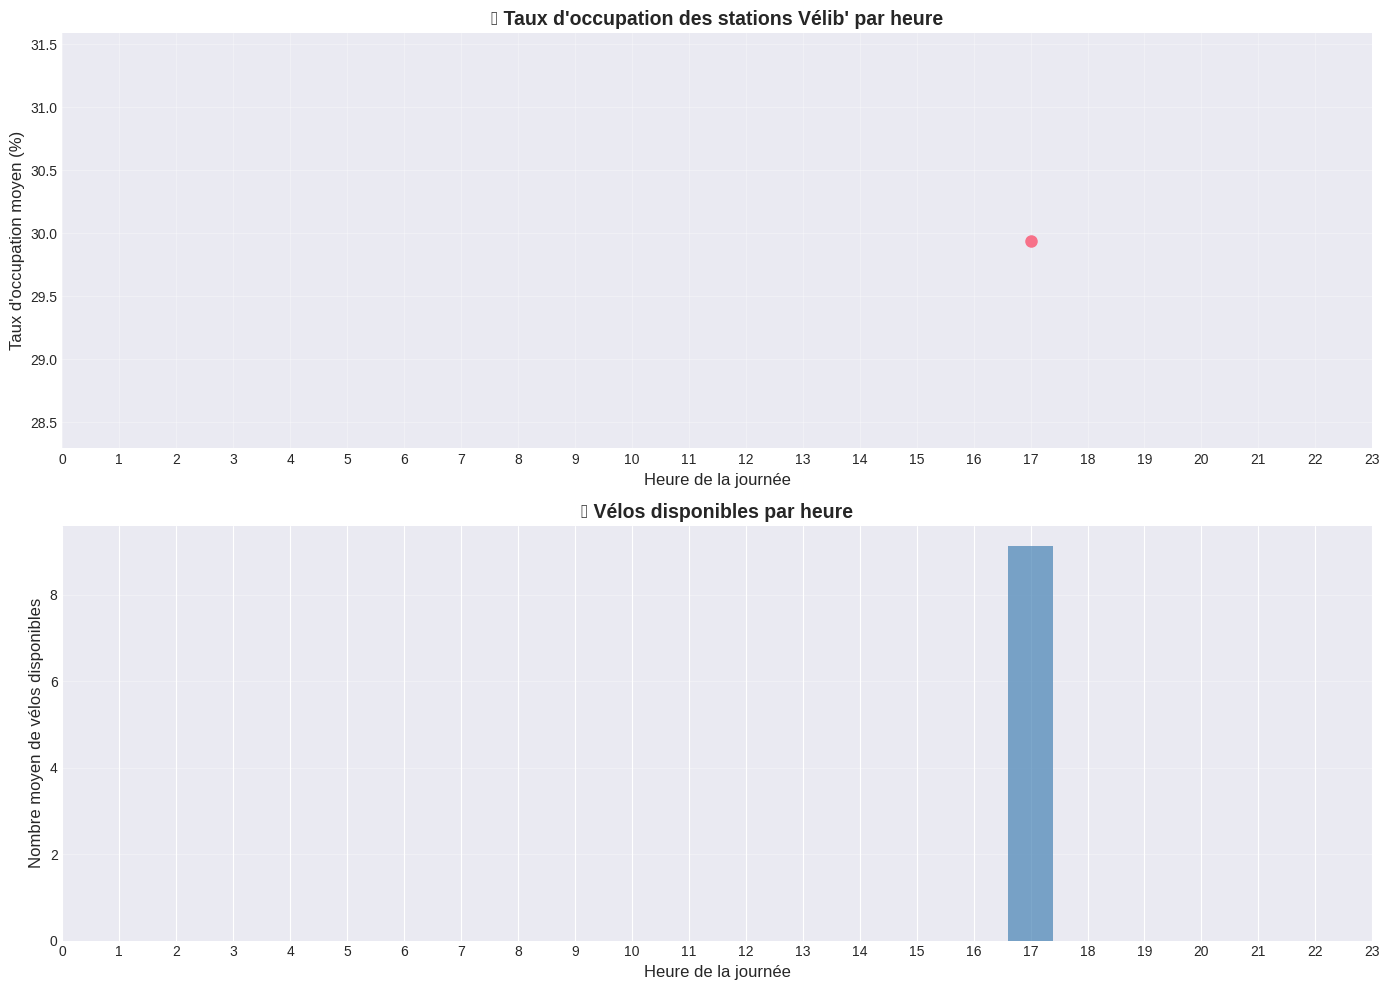

💾 Graphique sauvegardé: hourly_analysis.png


In [ ]:
# Visualisation
hourly_pd = hourly_stats.toPandas()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1: Occupation par heure
ax1.plot(hourly_pd['hour'], hourly_pd['occupation_avg'], marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Heure de la journée', fontsize=12)
ax1.set_ylabel('Taux d\'occupation moyen (%)', fontsize=12)
ax1.set_title('📊 Taux d\'occupation des stations Vélib\' par heure', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24))

# Graphique 2: Vélos disponibles par heure
ax2.bar(hourly_pd['hour'], hourly_pd['bikes_avg'], color='steelblue', alpha=0.7)
ax2.set_xlabel('Heure de la journée', fontsize=12)
ax2.set_ylabel('Nombre moyen de vélos disponibles', fontsize=12)
ax2.set_title('🚴 Vélos disponibles par heure', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('/home/jovyan/output/hourly_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Graphique sauvegardé: hourly_analysis.png")

In [ ]:
# Sauvegarder CSV
hourly_stats.coalesce(1).write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("/home/jovyan/output/hourly_patterns")

print("CSV sauvegardé: hourly_patterns/")

## 📊 ANALYSE 3: Par Période de la Journée

In [ ]:
period_stats = df.groupBy("time_period") \
    .agg(
        count("*").alias("nb_mesures"),
        avg("num_bikes_available").alias("bikes_avg"),
        avg("occupation_rate").alias("occupation_avg"),
        spark_sum(when(col("station_status") == "empty", 1).otherwise(0)).alias("empty_count"),
        spark_sum(when(col("station_status") == "full", 1).otherwise(0)).alias("full_count")
    ) \
    .withColumn("bikes_avg", spark_round(col("bikes_avg"), 2)) \
    .withColumn("occupation_avg", spark_round(col("occupation_avg"), 2))

print("\n Statistiques par période:")
period_stats.show(truncate=False)

In [ ]:
# Visualisation
period_pd = period_stats.toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(period_pd))
width = 0.35

ax.bar([i - width/2 for i in x], period_pd['bikes_avg'], width, label='Vélos dispo', color='green', alpha=0.7)
ax.bar([i + width/2 for i in x], period_pd['occupation_avg'], width, label='Taux occupation', color='orange', alpha=0.7)

ax.set_xlabel('Période de la journée', fontsize=12)
ax.set_ylabel('Valeur', fontsize=12)
ax.set_title('Disponibilité et Occupation par Période', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(period_pd['time_period'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/jovyan/output/period_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 📊 ANALYSE 4: Vélos Mécaniques vs Électriques

In [ ]:
bike_by_station = df.filter(
    col("mechanical_bikes").isNotNull() & col("electric_bikes").isNotNull()
).groupBy("name") \
    .agg(
        avg("mechanical_bikes").alias("mechanical_avg"),
        avg("electric_bikes").alias("electric_avg")
    ) \
    .withColumn("mechanical_avg", spark_round(col("mechanical_avg"), 2)) \
    .withColumn("electric_avg", spark_round(col("electric_avg"), 2)) \
    .withColumn("total_avg", col("mechanical_avg") + col("electric_avg")) \
    .withColumn("ratio_electric", 
               spark_round(col("electric_avg") / col("total_avg") * 100, 2))

print("\n🔋 Top 10 stations avec le plus de vélos électriques:")
bike_by_station.orderBy(col("electric_avg").desc()).show(10, truncate=False)

print("\n⚡ Top 10 stations avec le meilleur ratio électrique:")
bike_by_station.orderBy(col("ratio_electric").desc()).show(10, truncate=False)

## 📊 ANALYSE 5: Stations Problématiques

In [ ]:
problematic = df.groupBy("name", "station_id") \
    .agg(
        count("*").alias("total_observations"),
        spark_sum(when(col("station_status") == "empty", 1).otherwise(0)).alias("empty_count"),
        spark_sum(when(col("station_status") == "full", 1).otherwise(0)).alias("full_count")
    ) \
    .withColumn("empty_rate", 
               spark_round(col("empty_count") / col("total_observations") * 100, 2)) \
    .withColumn("full_rate", 
               spark_round(col("full_count") / col("total_observations") * 100, 2)) \
    .withColumn("problem_rate", col("empty_rate") + col("full_rate"))

print("\n Top 20 stations avec le plus de problèmes (souvent vides ou pleines):")
problematic.orderBy(col("problem_rate").desc()) \
    .select("name", "empty_rate", "full_rate", "problem_rate") \
    .show(20, truncate=False)

print("\n Top 10 stations souvent vides:")
problematic.orderBy(col("empty_rate").desc()) \
    .select("name", "empty_rate") \
    .show(10, truncate=False)

print("\n Top 10 stations souvent pleines:")
problematic.orderBy(col("full_rate").desc()) \
    .select("name", "full_rate") \
    .show(10, truncate=False)

In [ ]:
# Sauvegarder
problematic.coalesce(1).write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("/home/jovyan/output/problematic_stations")

print(" CSV sauvegardé")

## 📊 RÉSUMÉ GLOBAL

In [ ]:
# Statistiques globales
total_stations = df.select("station_id").distinct().count()
total_observations = df.count()

global_stats = df.agg(
    avg("num_bikes_available").alias("global_bikes_avg"),
    avg("num_docks_available").alias("global_docks_avg"),
    avg("occupation_rate").alias("global_occupation_avg"),
    spark_sum("capacity").alias("total_capacity")
).collect()[0]

summary = {
    "generated_at": datetime.now().isoformat(),
    "analysis_period": {
        "total_observations": total_observations,
        "total_stations": total_stations
    },
    "global_statistics": {
        "avg_bikes_available": round(global_stats["global_bikes_avg"], 2),
        "avg_docks_available": round(global_stats["global_docks_avg"], 2),
        "avg_occupation_rate": round(global_stats["global_occupation_avg"], 2),
        "total_system_capacity": int(global_stats["total_capacity"])
    },
    "top_occupied_stations": station_stats.limit(10).toPandas().to_dict('records'),
    "hourly_pattern": hourly_stats.toPandas().to_dict('records')
}

# Sauvegarder JSON
with open('/home/jovyan/output/global_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=str)

print("\n" + "="*80)
print(" STATISTIQUES GLOBALES")
print("="*80)
print(f"\n• Nombre total de stations: {total_stations}")
print(f"• Nombre total d'observations: {total_observations:,}")
print(f"• Vélos disponibles (moyenne): {round(global_stats['global_bikes_avg'], 2)}")
print(f"• Taux d'occupation moyen: {round(global_stats['global_occupation_avg'], 2)}%")
print(f"• Capacité totale du système: {int(global_stats['total_capacity']):,} vélos")
print("\n Résumé global sauvegardé: global_summary.json")

## ✅ Liste des fichiers générés

In [ ]:
import os

print("\n Fichiers générés dans /home/jovyan/output/:")
print("="*80)

for root, dirs, files in os.walk('/home/jovyan/output'):
    level = root.replace('/home/jovyan/output', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f"{subindent}📄 {file}")

print("\n Analyse Spark terminée avec succès !")

## 🛑 Fermer Spark

In [ ]:
# Fermer la session Spark
spark.stop()
print(" Session Spark fermée")